# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from math import floor
from sklearn.metrics import (accuracy_score,
                             classification_report,
                             confusion_matrix)
print("Import Done boss")

Import Done boss


# **Data Exploration**

## *Load The Data*

In [2]:
file_path = input("Enter the File Path: ")
df = pd.read_csv(file_path)
print('Data Loaded Boss')

Data Loaded Boss


## *Exploration*


In [3]:
print(f"The dataset have {df.shape[0]} Rows and {df.shape[1]} columns with {df.duplicated().sum()} duplicates")

The dataset have 32300 Rows and 10 columns with 298 duplicates


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32300 entries, 0 to 32299
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   vehicle_speed_kmh  31650 non-null  str    
 1   visibility_km      31651 non-null  float64
 2   road_type          31653 non-null  float64
 3   weather_condition  31649 non-null  float64
 4   hour_of_day        31655 non-null  float64
 5   driver_age         31655 non-null  float64
 6   vehicles_involved  31651 non-null  float64
 7   alcohol_involved   31654 non-null  float64
 8   seatbelt_worn      31653 non-null  float64
 9   severe_accident    32300 non-null  int64  
dtypes: float64(8), int64(1), str(1)
memory usage: 2.6 MB


In [5]:
df.head()

,vehicle_speed_kmh,visibility_km,road_type,weather_condition,hour_of_day,driver_age,vehicles_involved,alcohol_involved,seatbelt_worn,severe_accident
0,61.0,4.7,0.0,2.0,18.0,31.0,5.0,0.0,1.0,0
1,139.0,1.9,2.0,1.0,8.0,38.0,3.0,0.0,1.0,1
2,92.0,5.0,0.0,0.0,16.0,65.0,1.0,0.0,1.0,0
3,71.0,5.4,2.0,3.0,0.0,41.0,3.0,0.0,1.0,0
4,35.0,1.3,1.0,1.0,9.0,52.0,3.0,0.0,1.0,0


In [6]:
df.describe()

,visibility_km,road_type,weather_condition,hour_of_day,driver_age,vehicles_involved,alcohol_involved,seatbelt_worn,severe_accident
count,31651.000000,31653.000000,31649.000000,31655.000000,31655.000000,31651.000000,31654.000000,31653.000000,32300.000000
mean,5.064497,1.003001,1.504250,11.494835,47.896888,3.002338,0.120301,0.847029,0.499628
std,2.857235,0.816098,1.119893,6.900426,18.128484,1.414614,0.325318,0.359966,0.500008
min,-2.000000,0.000000,0.000000,0.000000,12.000000,1.000000,0.000000,0.000000,0.000000
25%,2.600000,0.000000,0.000000,6.000000,32.000000,2.000000,0.000000,1.000000,0.000000
50%,5.100000,1.000000,2.000000,11.000000,48.000000,3.000000,0.000000,1.000000,0.000000
75%,7.500000,2.000000,3.000000,17.000000,64.000000,4.000000,0.000000,1.000000,1.000000
max,10.000000,2.000000,3.000000,30.000000,79.000000,5.000000,1.000000,1.000000,1.000000


In [7]:
print("NaN values in columns: ")
print(df.isna().sum())

NaN values in columns: 
vehicle_speed_kmh    650
visibility_km        649
road_type            647
weather_condition    651
hour_of_day          645
driver_age           645
vehicles_involved    649
alcohol_involved     646
seatbelt_worn        647
severe_accident        0
dtype: int64


# **Data Cleaning**

## **Create Copy**

In [43]:
df_copy = df.copy()
print('copy created Boss')

copy created Boss


## **DataType**

In [44]:
df_copy['vehicle_speed_kmh'] = df_copy['vehicle_speed_kmh'].replace('_err','',regex=True).astype('float')

## **impossible values**

In [45]:
df_copy.loc[df_copy['vehicle_speed_kmh']<0,'vehicle_speed_kmh'] = np.nan

df_copy.loc[df_copy['visibility_km']<0,'visibility_km'] = np.nan

df_copy.loc[df_copy['hour_of_day']>24,'hour_of_day'] = np.nan

# df_copy.loc[df_copy['driver_age']<18,'driver_age'] = np.nan

## **Duplicates**

In [46]:
print("Dateset have duplicates: ")
print(f"Before: {df_copy.duplicated().sum()}")
df_copy.drop_duplicates(inplace=True)
print(f"After: {df_copy.duplicated().sum()}")

Dateset have duplicates: 
Before: 300
After: 0


## **NaN Columns**

### *Fill NaN*

In [47]:
print("NaN values in the Dataset is: ")
print(df_copy.isna().sum())
NaN_columns = df_copy.columns.tolist()
NaN_columns.remove('severe_accident')
for col in NaN_columns:
    df_copy[col] = df_copy[col].fillna(floor(df_copy[col].median()))
print("NaN values in the Dataset after filling is: ")
print(df_copy.isna().sum())

NaN values in the Dataset is: 
vehicle_speed_kmh    641
visibility_km        641
road_type            640
weather_condition    640
hour_of_day          641
driver_age           640
vehicles_involved    640
alcohol_involved     640
seatbelt_worn        640
severe_accident        0
dtype: int64
NaN values in the Dataset after filling is: 
vehicle_speed_kmh    0
visibility_km        0
road_type            0
weather_condition    0
hour_of_day          0
driver_age           0
vehicles_involved    0
alcohol_involved     0
seatbelt_worn        0
severe_accident      0
dtype: int64


### *Drop NaN*

In [ ]:
print("NaN values in the Dataset is: ")
print(df_copy.isna().sum())
df_copy.dropna(inplace=True)
print("NaN values in the Dataset after filling is: ")
print(df_copy.isna().sum())

# **Data Preperation**

In [48]:
X = df_copy[['vehicle_speed_kmh',
 'visibility_km',
 'road_type',
 'weather_condition',
 'hour_of_day',
 'driver_age',
 'vehicles_involved',
 'alcohol_involved',
 'seatbelt_worn']]

y = df_copy['severe_accident']

print(f"X Shape: {X.shape}")
print(f"y Shape: {y.shape}")

X Shape: (32000, 9)
y Shape: (32000,)


In [49]:
X_train,X_test,y_train,y_test = train_test_split(X,
                                                 y,
                                                 train_size=0.8,
                                                 random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f'y_train Shape: {y_train.shape}')
print(f'X_test Shape:  {X_test.shape}')
print(f'y_test Shape:  {y_test.shape}')

X_train shape: (25600, 9)
y_train Shape: (25600,)
X_test Shape:  (6400, 9)
y_test Shape:  (6400,)


# **Model**

## **Train**

In [50]:
model = RandomForestClassifier(max_depth=7,
                               n_estimators=100,
                               n_jobs=-1,
                               min_samples_split=100,
                               min_samples_leaf=50,
                               oob_score=True,
                               random_state=42)

model.fit(X_train, y_train)
print("Model trained ✅")

Model trained ✅


## **OOB Score**

In [51]:
print(f"OOB Score: {model.oob_score_:.4f}")

OOB Score: 0.7609


## **Test**

In [52]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

              precision    recall  f1-score   support

           0       0.75      0.76      0.75      3194
           1       0.76      0.75      0.75      3206

    accuracy                           0.75      6400
   macro avg       0.75      0.75      0.75      6400
weighted avg       0.75      0.75      0.75      6400

Accuracy: 0.7527


## **Features Importance**

             Feature  Importance
0  vehicle_speed_kmh      0.6891
1      visibility_km      0.0823
7   alcohol_involved      0.0763
8      seatbelt_worn      0.0578
6  vehicles_involved      0.0460
3  weather_condition      0.0222
5         driver_age      0.0149
2          road_type      0.0065
4        hour_of_day      0.0047


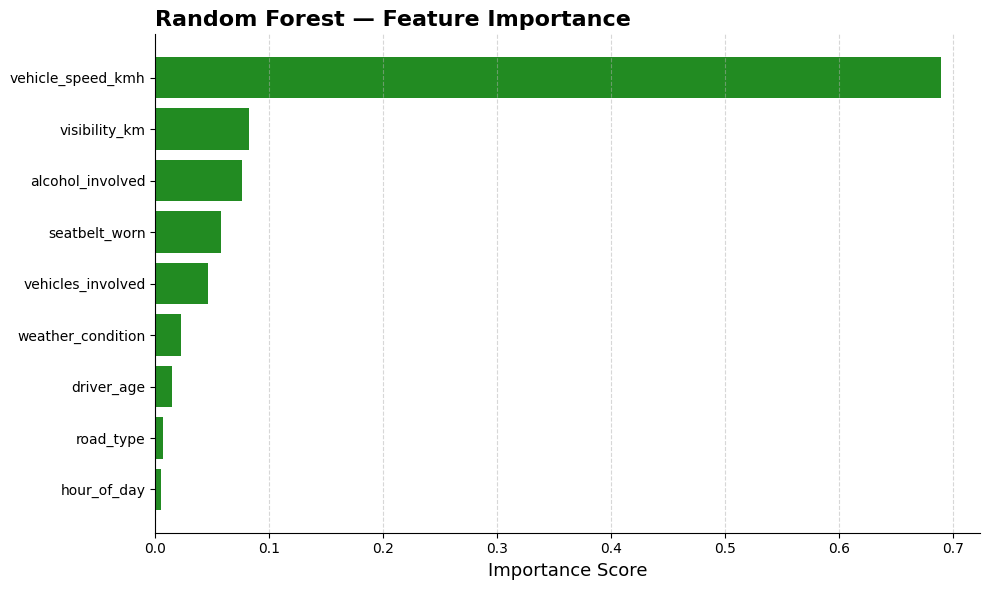

In [53]:
importance_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': model.feature_importances_.round(4)
}).sort_values('Importance', ascending=False)

print(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'],
         importance_df['Importance'],
         color='forestgreen')
ax = plt.gca()
ax.invert_yaxis()
ax.spines[['right','top']].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.5)
plt.xlabel('Importance Score', fontsize=13)
plt.title('Random Forest — Feature Importance',
          fontweight='bold', fontsize=16, loc='left')
plt.tight_layout()
plt.show()

## **Gap**

In [54]:
train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc  = accuracy_score(y_test, y_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Gap:               {(train_acc - test_acc):.4f}")
print(f"OOB Score:         {model.oob_score_:.4f}")

Training Accuracy: 0.7704
Testing Accuracy:  0.7527
Gap:               0.0178
OOB Score:         0.7609


## **How many tree is enough**

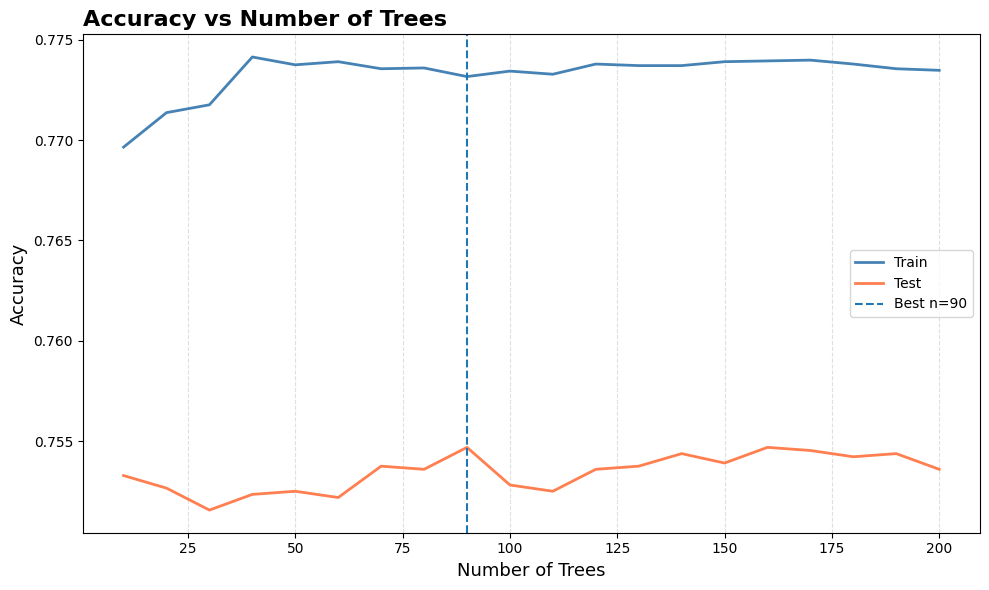

In [55]:
train_scores = []
test_scores  = []
tree_range   = range(10, 201, 10)

for n in tree_range:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1,max_depth=7)
    rf.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, rf.predict(X_train)))
    test_scores.append(accuracy_score(y_test, rf.predict(X_test)))

plt.figure(figsize=(10, 6))
plt.plot(tree_range, train_scores, label='Train', color='steelblue', linewidth=2)
plt.plot(tree_range, test_scores,  label='Test',  color='coral',     linewidth=2)
plt.xlabel('Number of Trees', fontsize=13)
plt.ylabel('Accuracy', fontsize=13)
plt.title('Accuracy vs Number of Trees',
          fontweight='bold', fontsize=16, loc='left')
ax = plt.gca()
ax.xaxis.grid(True,linestyle='--',alpha=0.4)

best_index = np.argmax(test_scores)
best_n = tree_range[best_index]
best_score = test_scores[best_index]
plt.axvline(best_n, linestyle='--', label=f'Best n={best_n}')

plt.legend()
plt.tight_layout()
plt.show()

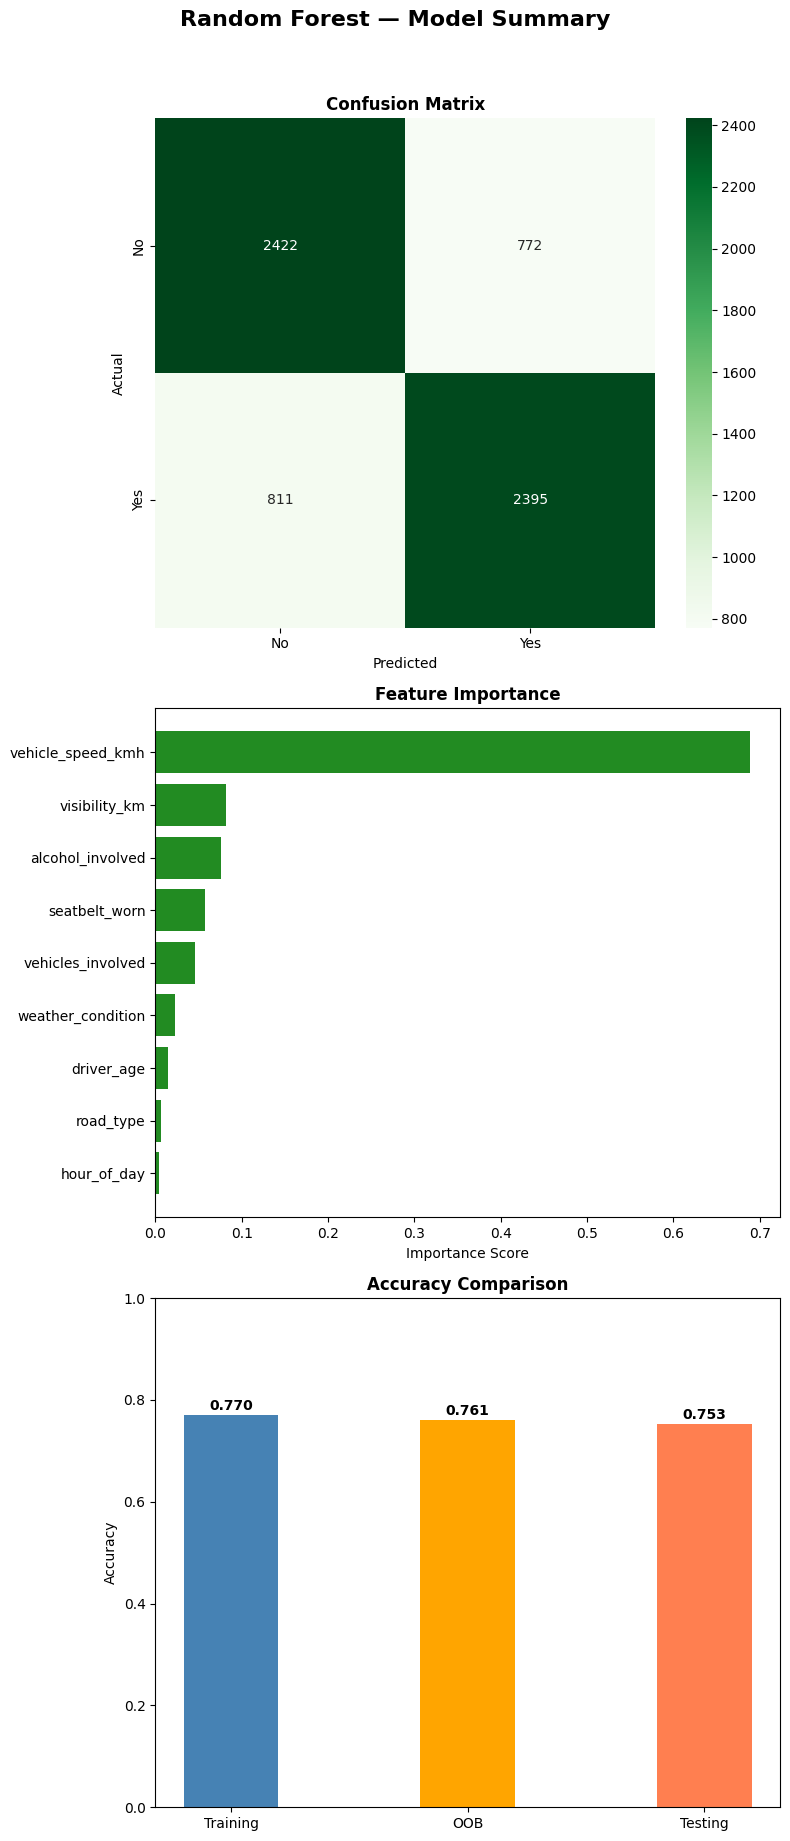

In [56]:
fig, axes = plt.subplots(3, 1, figsize=(8, 18))

# Plot 1 — Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Plot 2 — Feature Importance
imp = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance')
axes[1].barh(imp['Feature'], imp['Importance'], color='forestgreen')
axes[1].set_title('Feature Importance', fontweight='bold')
axes[1].set_xlabel('Importance Score')

# Plot 3 — Train vs Test vs OOB
labels = ['Training', 'OOB', 'Testing']
scores = [train_acc, model.oob_score_, test_acc]
colors = ['steelblue', 'orange', 'coral']
axes[2].bar(labels, scores, color=colors, width=0.4)
axes[2].set_ylim(0, 1)
axes[2].set_title('Accuracy Comparison', fontweight='bold')
axes[2].set_ylabel('Accuracy')
for i, v in enumerate(scores):
    axes[2].text(i, v + 0.01, f'{v:.3f}',
                 ha='center', fontweight='bold')

plt.suptitle('Random Forest — Model Summary',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()